# 📦 Inventory Level Optimization using Q-Learning
**Course: 21CSC571J — Reinforcement Learning Algorithms**

---



In [ ]:
# ── Cell 1: Install & Imports ──────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


---
## Step 1 — Inventory Environment


In [ ]:
# ── Cell 2: Environment Definition ────────────────────────────────────────
class InventoryEnv:
    """
    Inventory management environment.

    Parameters
    ----------
    max_capacity  : int   Maximum warehouse capacity
    mean_demand   : float Mean daily demand (Poisson)
    holding_cost  : float Cost per unit held overnight
    stockout_cost : float Penalty per unit of unmet demand
    ordering_cost : float Fixed cost charged when any order is placed
    n_bins        : int   Number of discrete inventory-level states
    """

    def __init__(self,
                 max_capacity  = 200,
                 mean_demand   = 20,
                 holding_cost  = 0.5,
                 stockout_cost = 5.0,
                 ordering_cost = 2.0,
                 n_bins        = 20):

        self.max_capacity  = max_capacity
        self.mean_demand   = mean_demand
        self.holding_cost  = holding_cost
        self.stockout_cost = stockout_cost
        self.ordering_cost = ordering_cost
        self.n_bins        = n_bins

        # Discrete action space: order quantities
        self.actions       = [0, 10, 20, 30, 40, 50]
        self.n_actions     = len(self.actions)

        # Bin edges for state discretisation
        self.bin_edges     = np.linspace(0, max_capacity, n_bins + 1)

        self.stock         = None

    # ── helpers ────────────────────────────────────────────────────────────
    def _discretize(self, stock):
        """Map continuous stock level → discrete state index."""
        return int(np.digitize(stock, self.bin_edges) - 1)

    # ── gym-style interface ─────────────────────────────────────────────────
    def reset(self):
        """Start a new episode with a random initial stock."""
        self.stock = np.random.randint(10, self.max_capacity // 2)
        return self._discretize(self.stock)

    def step(self, action_idx):
        """
        Execute one day of operations.

        Returns
        -------
        next_state : int
        reward     : float
        done       : bool  (always False — continuing task)
        info       : dict
        """
        order_qty = self.actions[action_idx]

        # Receive order (simplified: arrives same day)
        self.stock = min(self.stock + order_qty, self.max_capacity)

        # Stochastic demand
        demand    = np.random.poisson(self.mean_demand)
        sold      = min(demand, self.stock)
        stockout  = max(demand - self.stock, 0)
        self.stock = self.stock - sold

        # Reward signal (negate costs → maximise reward)
        r_hold     = -self.holding_cost  * self.stock
        r_stockout = -self.stockout_cost * stockout
        r_order    = -self.ordering_cost if order_qty > 0 else 0
        reward     = r_hold + r_stockout + r_order

        info = dict(order=order_qty, demand=demand,
                    sold=sold, stockout=stockout, stock=self.stock)

        return self._discretize(self.stock), reward, False, info


env = InventoryEnv()
print(f'State space  : {env.n_bins} discrete bins  (0 – {env.max_capacity} units)')
print(f'Action space : {env.n_actions} choices          {env.actions}')
print(f'Mean demand  : {env.mean_demand} units / day')

State space  : 20 discrete bins  (0 – 200 units)
Action space : 6 choices          [0, 10, 20, 30, 40, 50]
Mean demand  : 20 units / day


---
## Step 2 — Q-Learning Agent

In [ ]:
# ── Cell 3: Q-Learning Agent ───────────────────────────────────────────────
class QLearningAgent:
    """
    Tabular Q-Learning agent with ε-greedy exploration and linear ε decay.
    """

    def __init__(self,
                 n_states,
                 n_actions,
                 alpha       = 0.1,
                 gamma       = 0.95,
                 epsilon     = 1.0,
                 epsilon_min = 0.01,
                 epsilon_decay = 0.995):

        self.n_states      = n_states
        self.n_actions     = n_actions
        self.alpha         = alpha
        self.gamma         = gamma
        self.epsilon       = epsilon
        self.epsilon_min   = epsilon_min
        self.epsilon_decay = epsilon_decay

        # Q-table initialised to small random values (breaks symmetry)
        self.Q = np.random.uniform(-0.01, 0.01, (n_states, n_actions))

    def choose_action(self, state):
        """ε-greedy action selection."""
        if np.random.rand() < self.epsilon:
            return np.random.randint(self.n_actions)   # explore
        return np.argmax(self.Q[state])                # exploit

    def update(self, state, action, reward, next_state):
        """Bellman optimality update — core of Q-Learning."""
        td_target = reward + self.gamma * np.max(self.Q[next_state])
        td_error  = td_target - self.Q[state, action]
        self.Q[state, action] += self.alpha * td_error
        return td_error

    def decay_epsilon(self):
        """Anneal exploration rate after each episode."""
        self.epsilon = max(self.epsilon_min,
                           self.epsilon * self.epsilon_decay)

    def get_policy(self):
        """Extract greedy policy: best action index for each state."""
        return np.argmax(self.Q, axis=1)


agent = QLearningAgent(n_states=env.n_bins, n_actions=env.n_actions)
print('Q-table shape :', agent.Q.shape)
print(f'  rows = {env.n_bins} states  |  cols = {env.n_actions} actions')
print(f'  Initial ε = {agent.epsilon}  →  decays to ε_min = {agent.epsilon_min}')

Q-table shape : (20, 6)
  rows = 20 states  |  cols = 6 actions
  Initial ε = 1.0  →  decays to ε_min = 0.01


---
## Step 3 — Training Loop

In [ ]:
# ── Cell 4: Training ───────────────────────────────────────────────────────
N_EPISODES    = 2000
DAYS_PER_EP   = 365
LOG_EVERY     = 100

episode_rewards  = []
episode_epsilons = []
td_errors_log    = []

print(f'Training Q-Learning agent for {N_EPISODES} episodes × {DAYS_PER_EP} days ...\n')
print(f'{"Episode":>8}  {"Avg Reward":>12}  {"ε":>8}  {"Avg |TD error|":>14}')
print('-' * 52)

for ep in range(N_EPISODES):
    state     = env.reset()
    ep_reward = 0
    ep_td     = []

    for _ in range(DAYS_PER_EP):
        action              = agent.choose_action(state)
        next_state, reward, done, info = env.step(action)

        td_err = agent.update(state, action, reward, next_state)
        ep_td.append(abs(td_err))

        ep_reward += reward
        state      = next_state

    agent.decay_epsilon()

    episode_rewards.append(ep_reward)
    episode_epsilons.append(agent.epsilon)
    td_errors_log.append(np.mean(ep_td))

    if (ep + 1) % LOG_EVERY == 0:
        avg_r = np.mean(episode_rewards[-LOG_EVERY:])
        avg_td= np.mean(td_errors_log[-LOG_EVERY:])
        print(f'{ep+1:>8}  {avg_r:>12.1f}  {agent.epsilon:>8.4f}  {avg_td:>14.4f}')

print('\n✅ Training complete!')

Training Q-Learning agent for 2000 episodes × 365 days ...

 Episode    Avg Reward         ε  Avg |TD error|
----------------------------------------------------
     100      -17153.4    0.6058         14.0111
     200       -6385.4    0.3670          5.2646
     300       -4795.6    0.2223          4.4819
     400       -4080.5    0.1347          3.9862
     500       -3721.8    0.0816          3.7489
     600       -3535.3    0.0494          3.4302
     700       -3416.4    0.0299          3.4420
     800       -3272.2    0.0181          3.4780
     900       -3247.6    0.0110          3.1885
    1000       -3362.9    0.0100          2.6221
    1100       -3217.1    0.0100          3.4393
    1200       -3193.6    0.0100          3.3598
    1300       -3187.9    0.0100          3.3800
    1400       -3309.7    0.0100          2.9163
    1500       -3303.2    0.0100          2.9067
    1600       -3267.2    0.0100          3.1105
    1700       -3196.0    0.0100          3.4210
    1

---
## Step 4 — Visualise Learning Progress

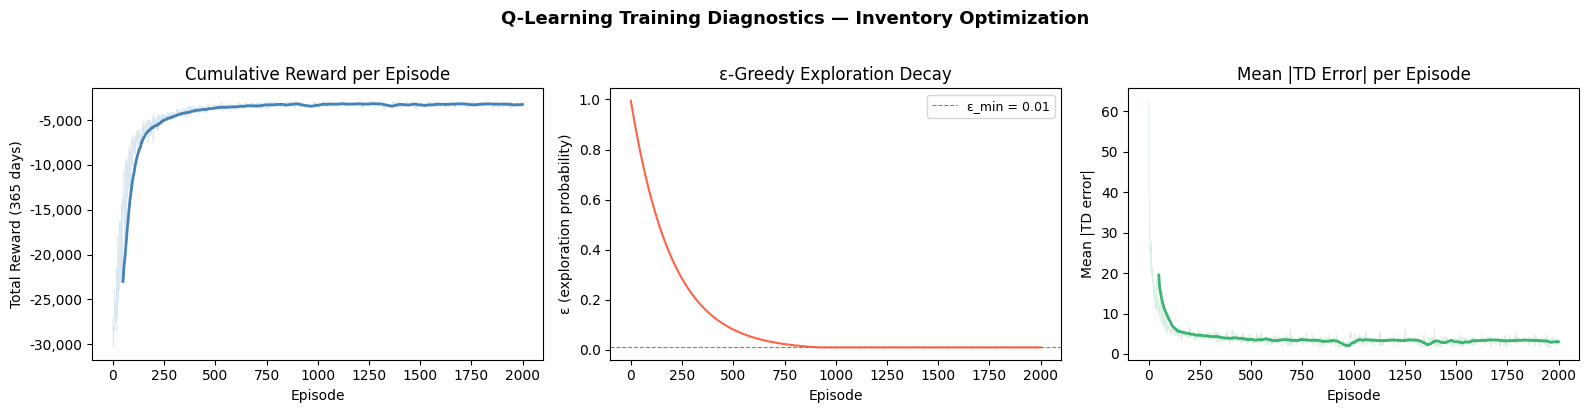

📊 Learning curves saved as learning_curves.png


In [ ]:
# ── Cell 5: Learning Curves ────────────────────────────────────────────────
window = 50
smooth = np.convolve(episode_rewards, np.ones(window)/window, mode='valid')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Q-Learning Training Diagnostics — Inventory Optimization',
             fontsize=13, fontweight='bold', y=1.02)

# ── Reward curve ──────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(episode_rewards, alpha=0.2, color='steelblue', linewidth=0.6)
ax.plot(range(window-1, N_EPISODES), smooth, color='steelblue', linewidth=2)
ax.set_title('Cumulative Reward per Episode')
ax.set_xlabel('Episode')
ax.set_ylabel('Total Reward (365 days)')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

# ── Epsilon decay ─────────────────────────────────────────────────────────
ax = axes[1]
ax.plot(episode_epsilons, color='tomato', linewidth=1.5)
ax.set_title('ε-Greedy Exploration Decay')
ax.set_xlabel('Episode')
ax.set_ylabel('ε (exploration probability)')
ax.axhline(y=agent.epsilon_min, linestyle='--', color='gray', linewidth=0.8,
           label=f'ε_min = {agent.epsilon_min}')
ax.legend(fontsize=9)

# ── TD error ──────────────────────────────────────────────────────────────
ax = axes[2]
smooth_td = np.convolve(td_errors_log, np.ones(window)/window, mode='valid')
ax.plot(td_errors_log, alpha=0.2, color='mediumseagreen', linewidth=0.6)
ax.plot(range(window-1, N_EPISODES), smooth_td, color='mediumseagreen', linewidth=2)
ax.set_title('Mean |TD Error| per Episode')
ax.set_xlabel('Episode')
ax.set_ylabel('Mean |TD error|')

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('📊 Learning curves saved as learning_curves.png')

---
## Step 5 — Learned Q-Table & Policy

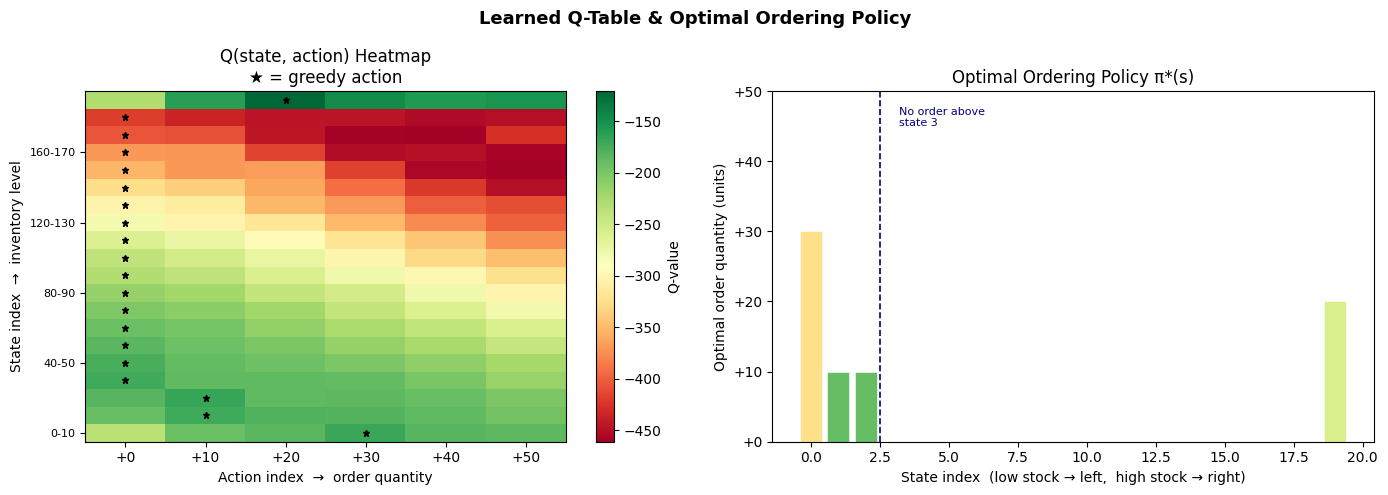


📋 Learned policy (state → optimal order):
 State      Inv. range   Optimal order
----------------------------------------
     0       0–10      +        30 units
     2      20–30      +        10 units
     4      40–50      +         0 units
     6      60–70      +         0 units
     8      80–90      +         0 units
    10     100–110     +         0 units
    12     120–130     +         0 units
    14     140–150     +         0 units
    16     160–170     +         0 units
    18     180–190     +         0 units


In [ ]:
# ── Cell 6: Q-Table Heatmap + Learned Policy ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Learned Q-Table & Optimal Ordering Policy',
             fontsize=13, fontweight='bold')

# ── Q-table heatmap ───────────────────────────────────────────────────────
ax = axes[0]
im = ax.imshow(agent.Q, aspect='auto', cmap='RdYlGn', origin='lower')
plt.colorbar(im, ax=ax, label='Q-value')
ax.set_title('Q(state, action) Heatmap')
ax.set_xlabel('Action index  →  order quantity')
ax.set_ylabel('State index  →  inventory level')
ax.set_xticks(range(env.n_actions))
ax.set_xticklabels([f'+{a}' for a in env.actions])
ax.set_yticks(range(0, env.n_bins, 4))
stock_labels = [f'{int(env.bin_edges[i])}-{int(env.bin_edges[i+1])}'
                for i in range(0, env.n_bins, 4)]
ax.set_yticklabels(stock_labels, fontsize=8)

# Mark greedy action per row
policy = agent.get_policy()
for s in range(env.n_bins):
    ax.plot(policy[s], s, 'k*', markersize=5)
ax.set_title('Q(state, action) Heatmap\n★ = greedy action')

# ── Learned policy bar chart ──────────────────────────────────────────────
ax = axes[1]
optimal_orders = [env.actions[p] for p in policy]
state_centers  = [(env.bin_edges[i] + env.bin_edges[i+1]) / 2
                  for i in range(env.n_bins)]

colors = plt.cm.RdYlGn_r(
    np.array(optimal_orders) / max(env.actions)
)
bars = ax.bar(range(env.n_bins), optimal_orders, color=colors, edgecolor='white', linewidth=0.4)
ax.set_title('Optimal Ordering Policy π*(s)')
ax.set_xlabel('State index  (low stock → left,  high stock → right)')
ax.set_ylabel('Optimal order quantity (units)')
ax.set_yticks(env.actions)
ax.set_yticklabels([f'+{a}' for a in env.actions])

# Annotate reorder threshold
threshold = next((i for i, o in enumerate(optimal_orders) if o == 0), None)
if threshold:
    ax.axvline(x=threshold - 0.5, color='navy', linestyle='--', linewidth=1.2)
    ax.text(threshold + 0.2, max(env.actions) * 0.9,
            f'No order above\nstate {threshold}',
            fontsize=8, color='navy')

plt.tight_layout()
plt.savefig('policy.png', dpi=120, bbox_inches='tight')
plt.show()

print('\n📋 Learned policy (state → optimal order):')
print(f'{"State":>6}  {"Inv. range":>14}  {"Optimal order":>14}')
print('-' * 40)
for i in range(0, env.n_bins, 2):
    lo = int(env.bin_edges[i])
    hi = int(env.bin_edges[i+1])
    print(f'{i:>6}  {lo:>6}–{hi:<6}  +{optimal_orders[i]:>10} units')

---
## Step 6 — Policy Evaluation: Greedy vs Random vs Conservative


📊 Policy Comparison (365-day horizon, 50 runs):
Policy                  Avg Reward       Std   Stockout days   Avg stock
------------------------------------------------------------------------
Q-Learning (ours)          -3133.6     105.3           113.6        10.1
Random                    -28378.0    1539.5            11.4       151.8
Fixed order=20            -13814.9    6336.7            21.1        71.1


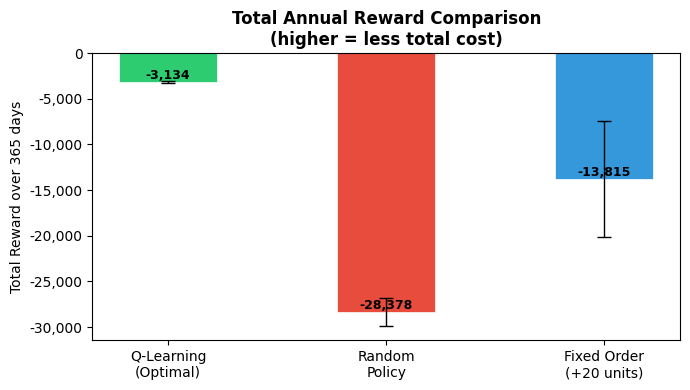

In [ ]:
# ── Cell 7: Policy Comparison ─────────────────────────────────────────────
def evaluate_policy(policy_fn, n_days=365, n_runs=50):
    """Run multiple simulations and collect statistics."""
    all_rewards, all_stockouts, all_stocks = [], [], []
    for _ in range(n_runs):
        state = env.reset()
        total_r, total_so, daily_stocks = 0, 0, []
        for _ in range(n_days):
            action_idx = policy_fn(state)
            state, r, _, info = env.step(action_idx)
            total_r  += r
            total_so += info['stockout']
            daily_stocks.append(info['stock'])
        all_rewards.append(total_r)
        all_stockouts.append(total_so)
        all_stocks.append(np.mean(daily_stocks))
    return (np.mean(all_rewards), np.std(all_rewards),
            np.mean(all_stockouts), np.mean(all_stocks))

# Three policies to compare
ql_policy     = lambda s: int(policy[s])
random_policy = lambda s: np.random.randint(env.n_actions)
fixed_policy  = lambda s: 2    # always order 20 units

r_ql,  sd_ql,  so_ql,  avg_s_ql  = evaluate_policy(ql_policy)
r_rnd, sd_rnd, so_rnd, avg_s_rnd = evaluate_policy(random_policy)
r_fix, sd_fix, so_fix, avg_s_fix = evaluate_policy(fixed_policy)

print('\n📊 Policy Comparison (365-day horizon, 50 runs):')
print(f'{"Policy":<20}  {"Avg Reward":>12}  {"Std":>8}  {"Stockout days":>14}  {"Avg stock":>10}')
print('-' * 72)
print(f'{"Q-Learning (ours)":<20}  {r_ql:>12.1f}  {sd_ql:>8.1f}  {so_ql:>14.1f}  {avg_s_ql:>10.1f}')
print(f'{"Random":<20}  {r_rnd:>12.1f}  {sd_rnd:>8.1f}  {so_rnd:>14.1f}  {avg_s_rnd:>10.1f}')
print(f'{"Fixed order=20":<20}  {r_fix:>12.1f}  {sd_fix:>8.1f}  {so_fix:>14.1f}  {avg_s_fix:>10.1f}')

# Bar chart comparison
labels  = ['Q-Learning\n(Optimal)', 'Random\nPolicy', 'Fixed Order\n(+20 units)']
rewards = [r_ql, r_rnd, r_fix]
colors  = ['#2ecc71', '#e74c3c', '#3498db']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(labels, rewards, color=colors, width=0.45,
              edgecolor='white', linewidth=0.5)
ax.errorbar(labels, rewards,
            yerr=[sd_ql, sd_rnd, sd_fix],
            fmt='none', color='black', capsize=5, linewidth=1)
ax.set_title('Total Annual Reward Comparison\n(higher = less total cost)', fontweight='bold')
ax.set_ylabel('Total Reward over 365 days')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
for bar, val in zip(bars, rewards):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:,.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Step 7 — Real-Time Simulation with Learned Policy

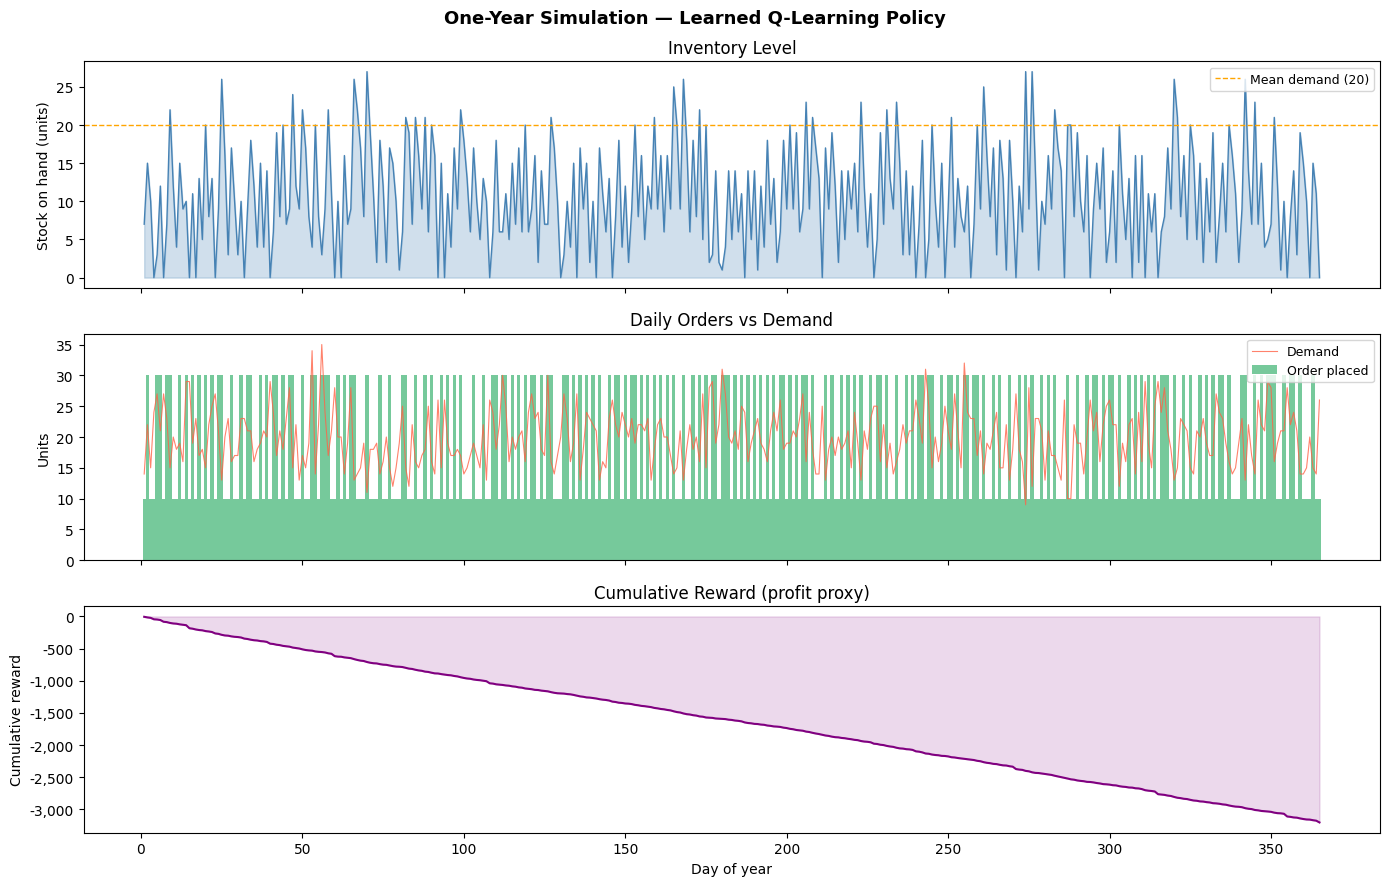


📈 Simulation summary:
  Total reward     : -3,201.0
  Avg daily stock  : 10.7 units
  Total ordered    : 7150 units
  Total demand     : 7263 units
  Stockout days    : 278 / 365


In [ ]:
# ── Cell 8: Simulate One Year with Learned Policy ──────────────────────────
state       = env.reset()
stocks, orders, demands, rewards_sim = [], [], [], []

for day in range(365):
    action_idx           = ql_policy(state)
    next_state, r, _, info = env.step(action_idx)
    stocks.append(info['stock'])
    orders.append(info['order'])
    demands.append(info['demand'])
    rewards_sim.append(r)
    state = next_state

days = np.arange(1, 366)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
fig.suptitle('One-Year Simulation — Learned Q-Learning Policy',
             fontsize=13, fontweight='bold')

# Stock level
ax = axes[0]
ax.fill_between(days, stocks, alpha=0.25, color='steelblue')
ax.plot(days, stocks, color='steelblue', linewidth=1)
ax.axhline(y=env.mean_demand, color='orange', linestyle='--',
           linewidth=1, label=f'Mean demand ({env.mean_demand})')
ax.set_ylabel('Stock on hand (units)')
ax.set_title('Inventory Level')
ax.legend(fontsize=9)

# Orders vs Demand
ax = axes[1]
ax.bar(days, orders, color='mediumseagreen', alpha=0.7, label='Order placed', width=1)
ax.plot(days, demands, color='tomato', linewidth=0.8, alpha=0.8, label='Demand')
ax.set_ylabel('Units')
ax.set_title('Daily Orders vs Demand')
ax.legend(fontsize=9)

# Cumulative reward
ax = axes[2]
cum_r = np.cumsum(rewards_sim)
ax.plot(days, cum_r, color='purple', linewidth=1.5)
ax.fill_between(days, cum_r, alpha=0.15, color='purple')
ax.set_xlabel('Day of year')
ax.set_ylabel('Cumulative reward')
ax.set_title('Cumulative Reward (profit proxy)')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('simulation.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\n📈 Simulation summary:')
print(f'  Total reward     : {sum(rewards_sim):,.1f}')
print(f'  Avg daily stock  : {np.mean(stocks):.1f} units')
print(f'  Total ordered    : {sum(orders)} units')
print(f'  Total demand     : {sum(demands)} units')
stockout_days = sum(1 for d, s in zip(demands, stocks) if d > s)
print(f'  Stockout days    : {stockout_days} / 365')

---
## Step 8 — Hyperparameter Sensitivity Study

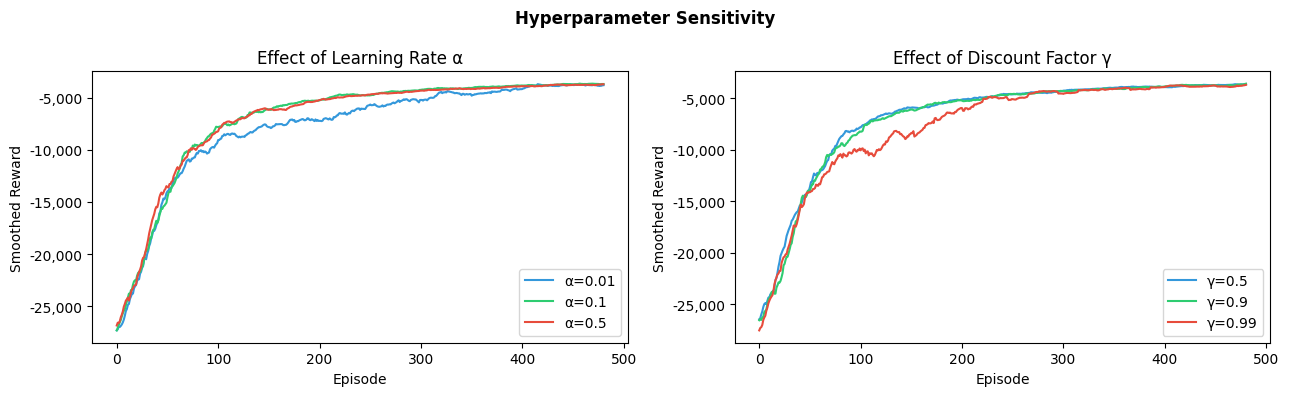

In [ ]:
# ── Cell 9: Alpha & Gamma Sensitivity ─────────────────────────────────────
def train_agent(alpha, gamma, n_episodes=500, n_days=365):
    env2  = InventoryEnv()
    agent2= QLearningAgent(env2.n_bins, env2.n_actions,
                           alpha=alpha, gamma=gamma)
    rewards = []
    for _ in range(n_episodes):
        s = env2.reset(); ep_r = 0
        for _ in range(n_days):
            a = agent2.choose_action(s)
            ns, r, _, _ = env2.step(a)
            agent2.update(s, a, r, ns)
            ep_r += r; s = ns
        agent2.decay_epsilon()
        rewards.append(ep_r)
    return np.convolve(rewards, np.ones(20)/20, mode='valid')

alphas = [0.01, 0.1, 0.5]
gammas = [0.5, 0.9, 0.99]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Hyperparameter Sensitivity', fontsize=12, fontweight='bold')

cols = ['#3498db', '#2ecc71', '#e74c3c']
for i, a in enumerate(alphas):
    curve = train_agent(alpha=a, gamma=0.95)
    axes[0].plot(curve, label=f'α={a}', color=cols[i], linewidth=1.5)
axes[0].set_title('Effect of Learning Rate α')
axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Smoothed Reward')
axes[0].legend(); axes[0].yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

for i, g in enumerate(gammas):
    curve = train_agent(alpha=0.1, gamma=g)
    axes[1].plot(curve, label=f'γ={g}', color=cols[i], linewidth=1.5)
axes[1].set_title('Effect of Discount Factor γ')
axes[1].set_xlabel('Episode'); axes[1].set_ylabel('Smoothed Reward')
axes[1].legend(); axes[1].yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

plt.tight_layout()
plt.savefig('hyperparams.png', dpi=120, bbox_inches='tight')
plt.show()